## Lab - EDA Bivariate Analysis: Diving into Amazon UK Product Insights Part II

**Objective**: Delve into the dynamics of product pricing on Amazon UK to uncover insights that can inform business strategies and decision-making.

**Dataset**: This lab utilizes the [Amazon UK product dataset](https://www.kaggle.com/datasets/asaniczka/uk-optimal-product-price-prediction/)
which provides information on product categories, brands, prices, ratings, and more from from Amazon UK. You'll need to download it to start working with it.

---

### Part 1: Analyzing Best-Seller Trends Across Product Categories

**Objective**: Understand the relationship between product categories and their best-seller status.

1. **Crosstab Analysis**:
    - Create a crosstab between the product `category` and the `isBestSeller` status.
    
    - Are there categories where being a best-seller is more prevalent? 
    	
    	*Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion in descending order.*


2. **Statistical Tests**:
    - Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
    - Compute Cramér's V to understand the strength of association between best-seller status and category.

3. **Visualizations**:
	- Visualize the relationship between product categories and the best-seller status using a stacked bar chart.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

df_amazon=pd.read_csv('C:/Users/ULI/ProjectsJupiter/data/amz_uk_price_prediction_dataset.csv')

1. Crosstab Analysis:

In [2]:
pd.crosstab(df_amazon['category'],df_amazon['isBestSeller'])


isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
...,...,...
Wind Instruments,243,7
Window Treatments,234,5
Women,17559,213


In [3]:
top_BestSeller = df_amazon.groupby('category')['isBestSeller'].sum().sort_values(ascending=False)[:10]
top_BestSeller

category
Grocery                   556
Health & Personal Care    552
Baby                      341
Sports & Outdoors         330
Power & Hand Tools        306
Beauty                    302
Pet Supplies              285
Arts & Crafts             230
Women                     213
Men                       169
Name: isBestSeller, dtype: int64

Grocery and Health & Personal Care are the most relevant category.

2. Statistical Test

In [4]:
from scipy.stats import chi2_contingency

In [5]:
chi_square_cat_bestSeller = pd.crosstab(df_amazon['category'], df_amazon['isBestSeller'])

chi2, p, dof, expected = chi2_contingency(chi_square_cat_bestSeller)

print(f"Chi-square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4e}")
print(f"DoF: {dof}")

Chi-square Statistic: 36540.2027
P-value: 0.0000e+00
DoF: 295


In [6]:
from scipy.stats.contingency import association

In [7]:
association(chi_square_cat_bestSeller, method='cramer')


0.1222829439760564

That means that even the p-value is less than 0.05, which means there is a relationship between the category and the best seller, as Cramer's value is 0.12, which means that the relationship between the category and the best seller is not strong enough; the best seller needs more variables than the category.

3. **Visualizations**:
	- Visualize the relationship between product categories and the best-seller status using a stacked bar chart.

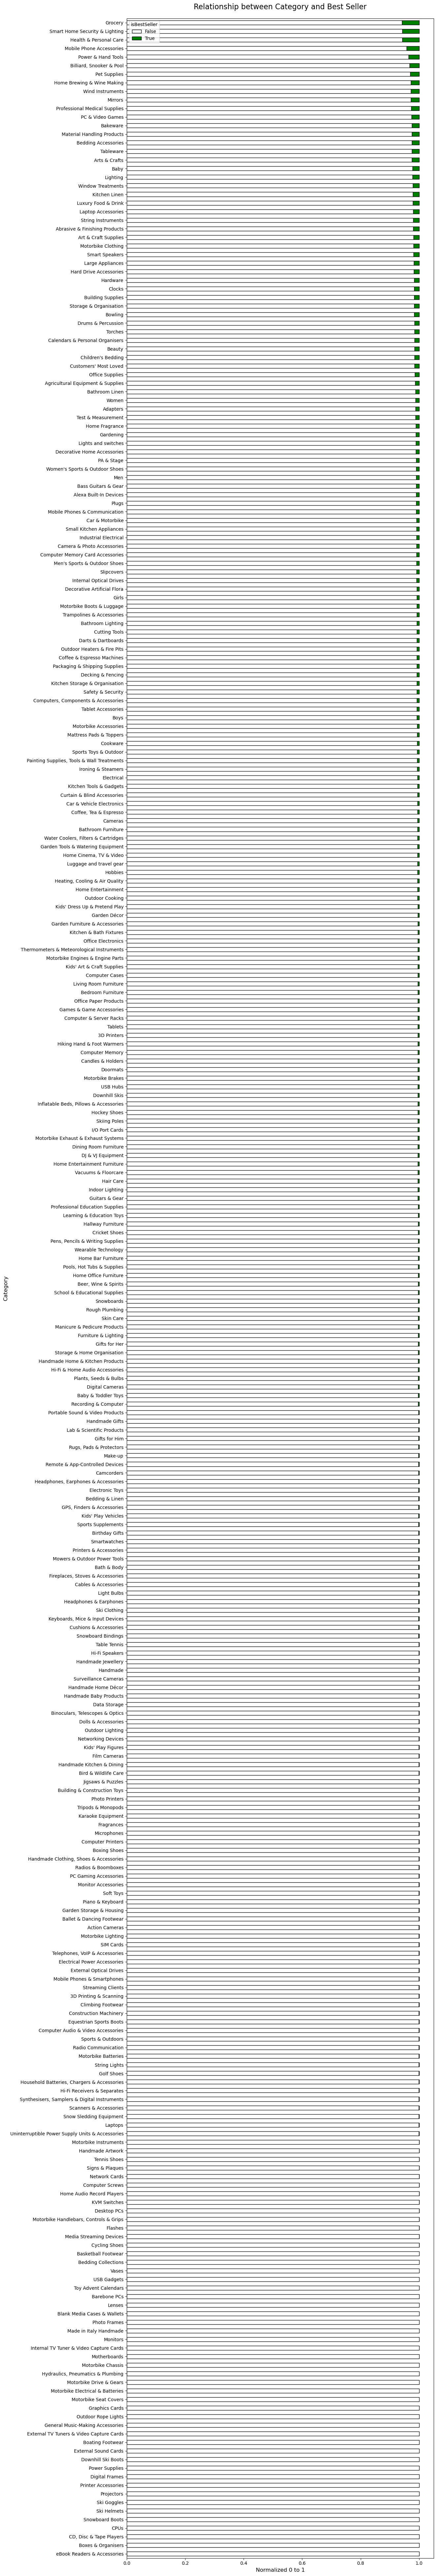

In [8]:
crosstab_cat_bs = pd.crosstab(df_amazon['category'], df_amazon['isBestSeller'], normalize='index')

crosstab_cat_bs = crosstab_cat_bs.sort_values(by=True, ascending=True)

crosstab_cat_bs.plot(kind='barh', 
                        stacked=True, 
                        figsize=(12, 100), 
                        color=['white', 'green'],
                        edgecolor='black',
                        legend=True)

plt.title('Relationship between Category and Best Seller', fontsize=16, pad=20)
plt.xlabel('Normalized 0 to 1', fontsize=12)
plt.ylabel('Category', fontsize=12)

plt.show()

### Part 2: Exploring Product Prices and Ratings Across Categories and Brands

**Objective**: Investigate how different product categories influence product prices.

0. **Preliminary Step: Remove outliers in product prices.**

	For this purpose, we can use the IQR (Interquartile Range) method. Products priced below the first quartile minus 1.5 times the IQR or above the third quartile plus 1.5 times the IQR will be considered outliers and removed from the dataset. The next steps will be done with the dataframe without outliers.
	
	*Hint: you can check the last Check For Understanding at the end of the lesson EDA Bivariate Analysis for a hint on how to do this.*

1. **Violin Plots**:
    - Use a violin plot to visualize the distribution of `price` across different product `categories`. Filter out the top 20 categories based on count for better visualization.
    - Which product category tends to have the highest median price? Don't filter here by top categories.

2. **Bar Charts**:
    - Create a bar chart comparing the average price of products for the top 10 product categories (based on count).
    - Which product category commands the highest average price? Don't filter here by top categories.

3. **Box Plots**:
    - Visualize the distribution of product `ratings` based on their `category` using side-by-side box plots. Filter out the top 10 categories based on count for better visualization.
    - Which category tends to receive the highest median rating from customers? Don't filter here by top categories.

---

0. **Preliminary Step: Remove outliers in product prices.**

	For this purpose, we can use the IQR (Interquartile Range) method. Products priced below the first quartile minus 1.5 times the IQR or above the third quartile plus 1.5 times the IQR will be considered outliers and removed from the dataset. The next steps will be done with the dataframe without outliers.
	
	*Hint: you can check the last Check For Understanding at the end of the lesson EDA Bivariate Analysis for a hint on how to do this.*

In [9]:
q1 = df_amazon.groupby('category')['price'].transform('quantile', 0.25)
q3 = df_amazon.groupby('category')['price'].transform('quantile', 0.75)

iqr=q3-q1


lower_iqr = q1 - 1.5 * iqr
Upper_iqr = q3 + 1.5 * iqr

In [10]:
df_cleaned = df_amazon[(df_amazon['price'] >= lower_iqr) & (df_amazon['price'] <= Upper_iqr)]

1. **Violin Plots**:
    - Use a violin plot to visualize the distribution of `price` across different product `categories`. Filter out the top 20 categories based on count for better visualization.
    - Which product category tends to have the highest median price? Don't filter here by top categories.


In [11]:
df_cleaned

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers
...,...,...,...,...,...,...,...,...,...
2443646,2828589,B0CHSD7P2Q,"Motorbike Armour, Motorbike Clothing, Cycling ...",0.0,0,22.34,False,0,Motorbike Clothing
2443647,2828590,B0B7B8FNBQ,PROFIRST Waterproof Motorcycle 2 Piece Ladies ...,0.0,0,97.99,False,0,Motorbike Clothing
2443648,2828591,B0BD5FL5FB,Men’s Motorcycle Motorbike Biker Trousers Kevl...,0.0,0,52.99,False,0,Motorbike Clothing
2443649,2828592,B008OYLL4I,Texpeed Mens Motorcycle Motorbike Biker Trouse...,4.3,404,79.99,False,0,Motorbike Clothing


In [12]:
top20_cat = df_cleaned['category'].value_counts().nlargest(20).index
top20_cat

Index(['Sports & Outdoors', 'Bath & Body', 'Beauty',
       'Handmade Clothing, Shoes & Accessories', 'Skin Care', 'Hair Care',
       'Manicure & Pedicure Products', 'Fragrances', 'Make-up',
       'Birthday Gifts', 'Handmade Kitchen & Dining', 'Handmade Gifts',
       'Handmade Home Décor', 'Handmade Jewellery', 'Handmade Artwork',
       'Luggage and travel gear', 'Women', 'Handmade Home & Kitchen Products',
       'Men', 'Baby'],
      dtype='object', name='category')

In [13]:
df_top20_cat = df_cleaned[df_cleaned['category'].isin(top20_cat)]


<Axes: xlabel='price', ylabel='category'>

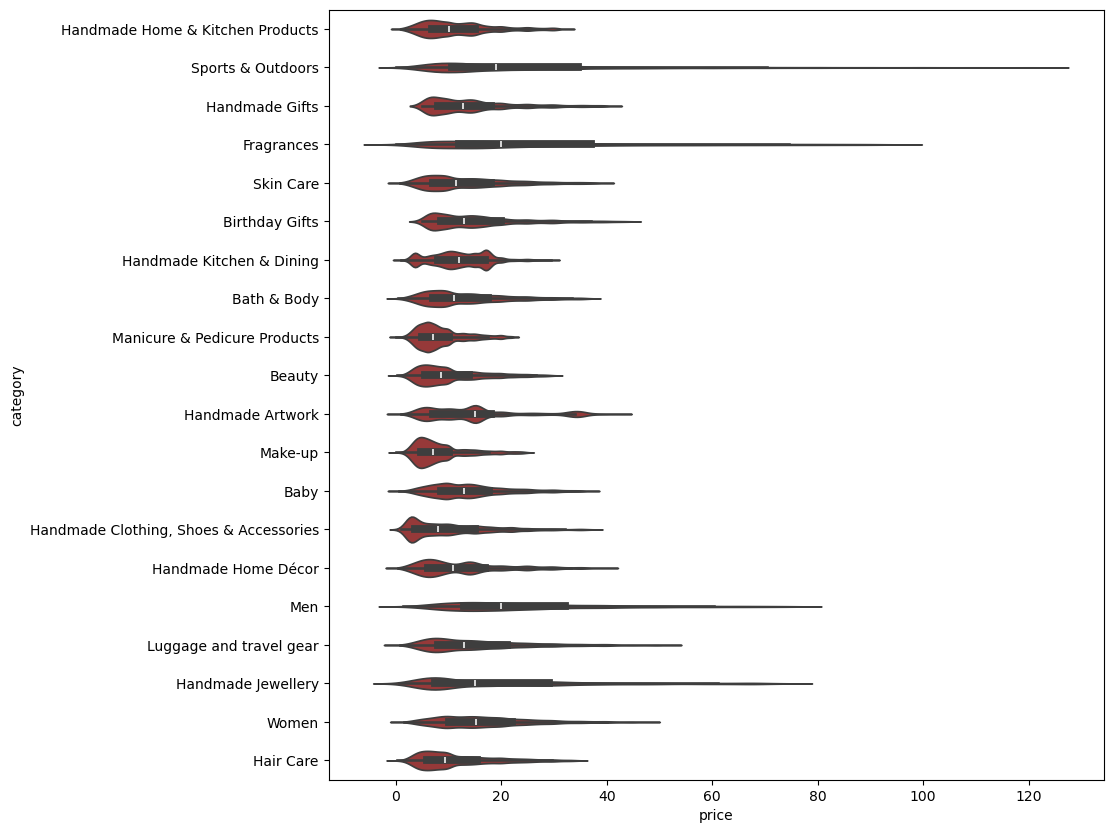

In [14]:
plt.figure(figsize=(10, 10))
sns.violinplot(data=df_top20_cat,x='price',y='category',color='brown')


In [15]:
high_median_prices = df_cleaned.groupby('category')['price'].median().sort_values(ascending=False)
high_median_prices

category
Laptops                                1008.500
Desktop PCs                             799.000
Snowboards                              354.990
Motorbike Exhaust & Exhaust Systems     305.860
Home Audio Record Players               294.990
                                         ...   
Bedding Accessories                       6.990
Make-up                                   6.985
Signs & Plaques                           6.680
Arts & Crafts                             5.970
Office Paper Products                     3.990
Name: price, Length: 296, dtype: float64

The category with the highest median is Laptops category and the median is 1008.5$

2. **Bar Charts**:
    - Create a bar chart comparing the average price of products for the top 10 product categories (based on count).
    - Which product category commands the highest average price? Don't filter here by top categories.

In [16]:
top10_cat = df_cleaned['category'].value_counts().nlargest(10).index
top10_cat

Index(['Sports & Outdoors', 'Bath & Body', 'Beauty',
       'Handmade Clothing, Shoes & Accessories', 'Skin Care', 'Hair Care',
       'Manicure & Pedicure Products', 'Fragrances', 'Make-up',
       'Birthday Gifts'],
      dtype='object', name='category')

In [17]:
df_top10_cat=df_cleaned[df_cleaned['category'].isin(top10_cat)]
df_top10_cat

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
82163,89483,B07DLGZ828,Neutrade GoPro 3M Sticky Pads Double Sided Adh...,4.2,3116,6.49,False,0,Sports & Outdoors
82164,89484,B09HGZHXJT,"WOLFANG Action Camera 4K 20MP GA100, Waterproo...",4.2,2594,49.99,False,0,Sports & Outdoors
82167,89487,B08LD4VXGL,FitStill 60M/196FT Waterproof Case for Go Pro ...,4.5,9879,16.98,True,0,Sports & Outdoors
82168,89488,B07QDMLMJH,Nextbase Powered Mount Variations For Cameras ...,4.7,1223,19.95,False,0,Sports & Outdoors
82169,89489,B09TQMCNY7,WOLFANG Action Camera GA100 with 64GB microSDX...,4.2,55,49.99,False,0,Sports & Outdoors
...,...,...,...,...,...,...,...,...,...
2429088,2806950,B0045I6SHW,Cannondale Men's Bibshort Dart Team Bike Shorts,0.0,0,99.67,False,0,Sports & Outdoors
2429089,2806951,B0045I6NZY,Cannondale Men's Baggy Fitness Bike Shorts,0.0,0,20.62,False,0,Sports & Outdoors
2429090,2806952,B003BLON3A,Pearl iZUMi Men's Phase Splice Knicker,4.3,3,59.86,False,0,Sports & Outdoors
2437153,2818782,B091HG57TP,Goodstoworld Boys Girls Tracksuit Bottoms 3D S...,4.2,554,14.99,False,0,Sports & Outdoors


<Axes: xlabel='price', ylabel='category'>

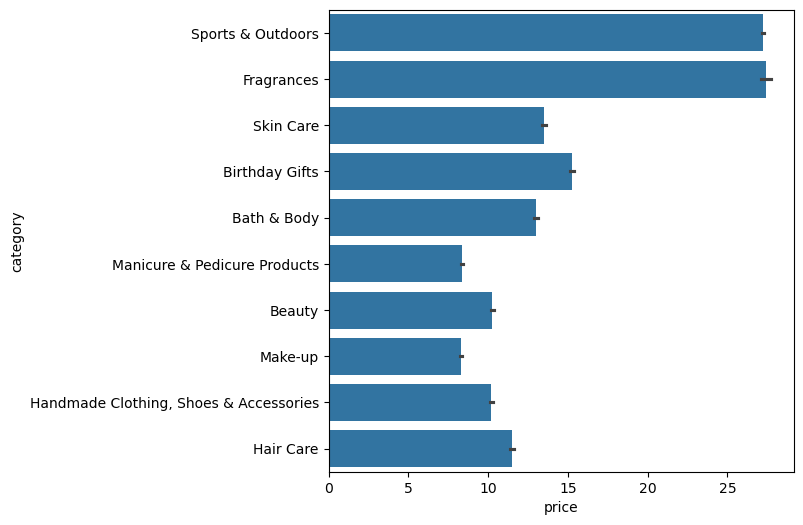

In [18]:
plt.figure(figsize=(6, 6))
sns.barplot(data=df_top10_cat,x='price',y='category',orient='h',)


which product category commands the highest average price? Don't filter here by top categories.

In [19]:
high_avg_price_top10=df_cleaned.groupby('category')['price'].mean().sort_values(ascending=False)
high_avg_price_top10

category
Laptops                      1003.005307
Desktop PCs                   885.540326
3D Printers                   424.232186
Home Audio Record Players     360.134731
Barebone PCs                  349.524252
                                ...     
Adapters                        7.383348
Bedding Accessories             7.343138
Signs & Plaques                 7.281398
Arts & Crafts                   6.927814
Office Paper Products           5.717727
Name: price, Length: 296, dtype: float64

3. **Box Plots**:
    - Visualize the distribution of product `ratings` based on their `category` using side-by-side box plots. Filter out the top 10 categories based on count for better visualization.
    - Which category tends to receive the highest median rating from customers? Don't filter here by top categories.

In [23]:
top10_cat= df_cleaned['category'].value_counts().nlargest(10).index

df_top10_cat_stars=df_cleaned[df_cleaned['category'].isin(top10_cat)]

<Axes: xlabel='stars', ylabel='category'>

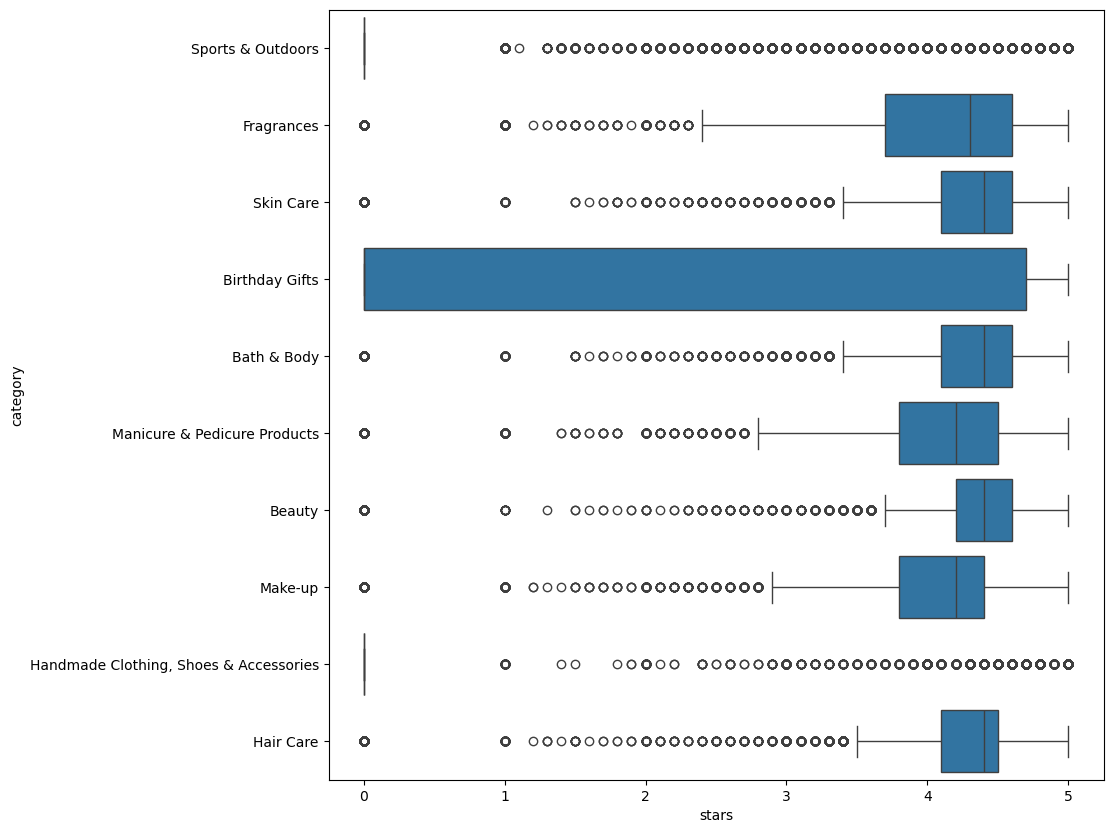

In [25]:
plt.figure(figsize=(10,10))
sns.boxplot(data=df_top10_cat_stars,x='stars',y='category')

In [26]:
high_avg_stars=df_cleaned.groupby('category')['stars'].median().sort_values(ascending=False)
high_avg_stars

category
Computer Memory                4.65
Kids' Play Figures             4.60
Office Paper Products          4.60
Jigsaws & Puzzles              4.60
Laptop Accessories             4.60
                               ... 
KVM Switches                   0.00
Karaoke Equipment              0.00
Lab & Scientific Products      0.00
Laptops                        0.00
eBook Readers & Accessories    0.00
Name: stars, Length: 296, dtype: float64

Computer Memory has the highest category median with 4.65/5.

### Part 3: Investigating the Interplay Between Product Prices and Ratings

**Objective**: Analyze how product ratings (`stars`) correlate with product prices.

1. **Correlation Coefficients**:
    - Calculate the correlation coefficient between `price` and `stars`.
    - Is there a significant correlation between product price and its rating?
	
2. **Visualizations**:
    - Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe?
    - Use a correlation heatmap to visualize correlations between all numerical variables.
    - Examine if product prices typically follow a normal distribution using a QQ plot. 

---

**Submission**: Submit a Jupyter Notebook which contains code and a business-centric report summarizing your findings. 

**Bonus**: 

- Do the same analysis without taking out the outliers. What are your insights?


1. **Correlation Coefficients**:
    - Calculate the correlation coefficient between `price` and `stars`.
    - Is there a significant correlation between product price and its rating?

In [29]:
corr = df_amazon['price'].corr(df_amazon['stars'])
print(f"Correlation Coefficient: {corr}")

Correlation Coefficient: -0.1249067326214861


No correlation between product price and its rating.

2. **Visualizations**:
    - Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe?
    - Use a correlation heatmap to visualize correlations between all numerical variables.
    - Examine if product prices typically follow a normal distribution using a QQ plot. 

<Axes: xlabel='stars', ylabel='price'>

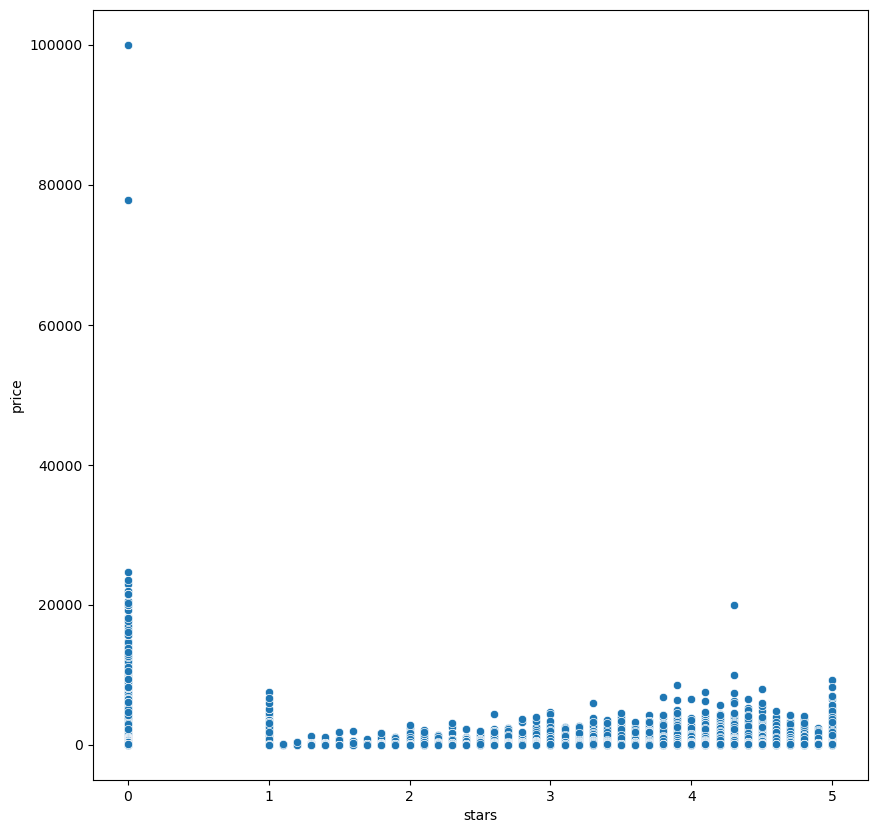

In [33]:
plt.figure(figsize=(10, 10))
sns.scatterplot(data=df_amazon, x='stars', y='price')

Buyers don't use to rate products when the price is higher than 10000.
Lower prices than 10000, the ratings are highers beween 3 and 5.

<Axes: >

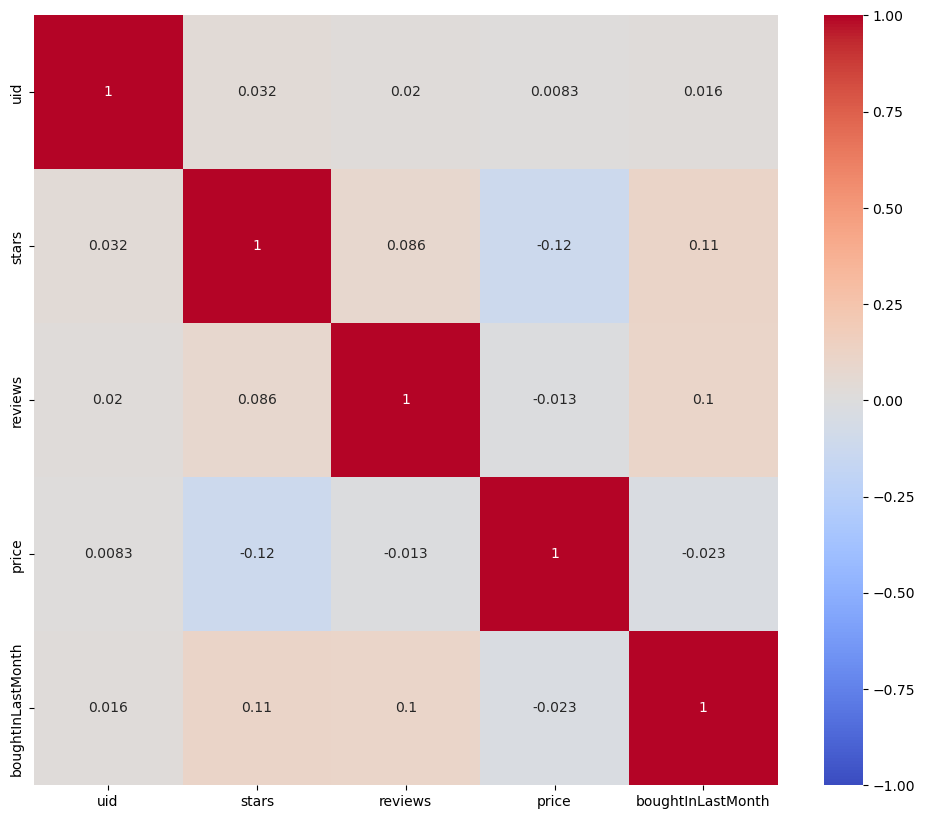

In [34]:
df_amazon_num = df_amazon.select_dtypes(include=['number'])

corr_matrix = df_amazon_num.corr()

plt.figure(figsize=(12, 10))

# 4. Creamos el heatmap
sns.heatmap(corr_matrix, 
            annot=True,       
            cmap='coolwarm',  
            vmin=-1, vmax=1)  



In [35]:
import statsmodels.api as sm

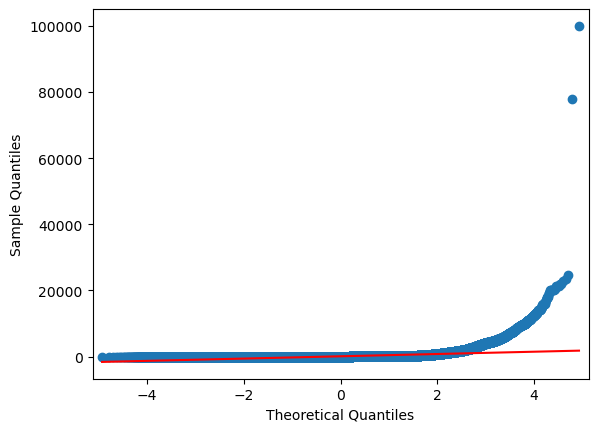

In [37]:
sm.qqplot(df_amazon.price,line='s')
plt.show()

Product prices don't follow a normal distribution, that figure shows that the highers prices modifies the distribution.